# Take-Home: Data Understanding — Sales Forecasting
## CRISP-DM Phase 2
All required Python code is provided. **You are not assessed on writing code.** Run each cell and write your evidence-based answers in Markdown.
Do **not** clean, delete, impute, encode, transform or model the data. Continue from your Week 1 Business Understanding and explicitly use the feedback you received.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns",None)
df=pd.read_csv("sales_forecasting.csv")
df.head()

,week_start,store_id,promo_flag,sales_eur
0,2023-01-01,S1,0,22837.23
1,2023-01-08,S1,0,23060.88
2,2023-01-15,S1,1,24246.42
3,2023-01-22,S1,0,24202.07
4,2023-01-29,S1,1,27813.74


## 1. Understand the dataset
Answer: What does one row represent? How many observations/variables are there? What is the identifier/business key? What is the main outcome? Which variables matter most to your business problem?

What does one row represent:

How many observations/variables are there:

What is the identifier/business key:

What is the main outcome:

Which variables matter most to your business problem


In [4]:
print("Shape:",df.shape)
df.info()
display(df.nunique(dropna=False).sort_values())

Shape: (1800, 4)
<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   week_start  1800 non-null   str    
 1   store_id    1800 non-null   str    
 2   promo_flag  1800 non-null   int64  
 3   sales_eur   1800 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 56.4 KB


promo_flag       2
store_id        15
week_start     120
sales_eur     1800
dtype: int64

### Your answer
**One row represents:** ...  
**Dimensions:** ...  
**Identifier/business key:** ...  
**Main outcome:** ...  
**Most relevant variables and why:** ...

## 2. Data quality — observe, do not fix
Identify missing values, duplicates, unexpected types/categories and implausible ranges. Explain why any issue could matter.

In [5]:
quality=pd.DataFrame({"type":df.dtypes.astype(str),"missing":df.isna().sum(),"unique":df.nunique(dropna=False)})
display(quality)
print("Exact duplicates:",df.duplicated().sum())
for col in df.select_dtypes(exclude="number").columns:
 print("\n",col); print(df[col].value_counts(dropna=False).head(20))

,type,missing,unique
week_start,str,0,120
store_id,str,0,15
promo_flag,int64,0,2
sales_eur,float64,0,1800


Exact duplicates: 0

 week_start
week_start
2023-01-01    15
2023-01-08    15
2023-01-15    15
2023-01-22    15
2023-01-29    15
2023-02-05    15
2023-02-12    15
2023-02-19    15
2023-02-26    15
2023-03-05    15
2023-03-12    15
2023-03-19    15
2023-03-26    15
2023-04-02    15
2023-04-09    15
2023-04-16    15
2023-04-23    15
2023-04-30    15
2023-05-07    15
2023-05-14    15
Name: count, dtype: int64

 store_id
store_id
S1     120
S2     120
S3     120
S4     120
S5     120
S6     120
S7     120
S8     120
S9     120
S10    120
S11    120
S12    120
S13    120
S14    120
S15    120
Name: count, dtype: int64


### Data-quality findings
| Observation/issue | Variable(s) | Evidence | Why it matters |
|---|---|---|---|
| | | | |
| | | | |
| | | | |

## 3. Summary statistics
Interpret important values rather than copying output. Give at least three observations and explain their business meaning.

In [6]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
week_start,1800,120,2023-01-01,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store_id,1800,15,S1,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
promo_flag,1800.0,NaN,NaN,NaN,0.501667,0.500136,0.0,0.0,1.0,1.0,1.0
sales_eur,1800.0,NaN,NaN,NaN,24207.731011,6768.072857,5246.41,18470.63,26039.41,29476.315,39668.57


### Your interpretation
1. **Evidence:** ... **Business meaning:** ...  
2. **Evidence:** ... **Business meaning:** ...  
3. **Evidence:** ... **Business meaning:** ...

## 4. Understand the main outcome: `sales_eur`
Explain its distribution in plain business language. Is it balanced, rare, concentrated, or continuous? Why might this matter later? What context is needed before calling the result good/bad?

sales_eur
22837.23    1
23060.88    1
24246.42    1
24202.07    1
27813.74    1
           ..
31589.54    1
26538.73    1
31240.64    1
28605.08    1
28715.72    1
Name: count, Length: 1800, dtype: int64
sales_eur
22837.23    0.06
23060.88    0.06
24246.42    0.06
24202.07    0.06
27813.74    0.06
            ... 
31589.54    0.06
26538.73    0.06
31240.64    0.06
28605.08    0.06
28715.72    0.06
Name: proportion, Length: 1800, dtype: float64


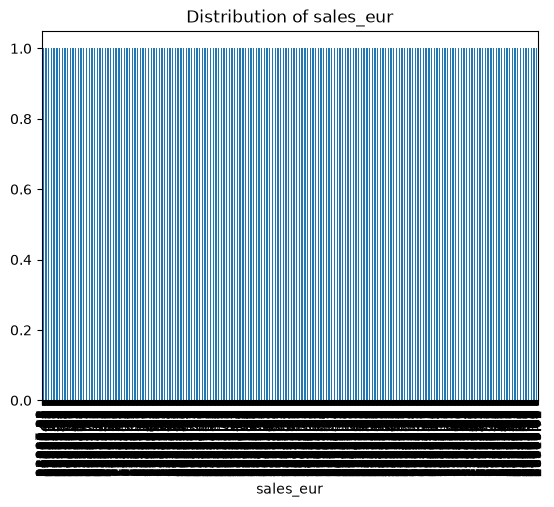

In [7]:
print(df["sales_eur"].value_counts(dropna=False))
print((df["sales_eur"].value_counts(normalize=True,dropna=False)*100).round(2))
df["sales_eur"].value_counts(dropna=False).plot(kind="bar",title="Distribution of sales_eur")
plt.show()

### Your outcome interpretation
...

## 5. Visual exploration
For every chart write: **Evidence → Business interpretation → Caution**. An association does not prove causation.

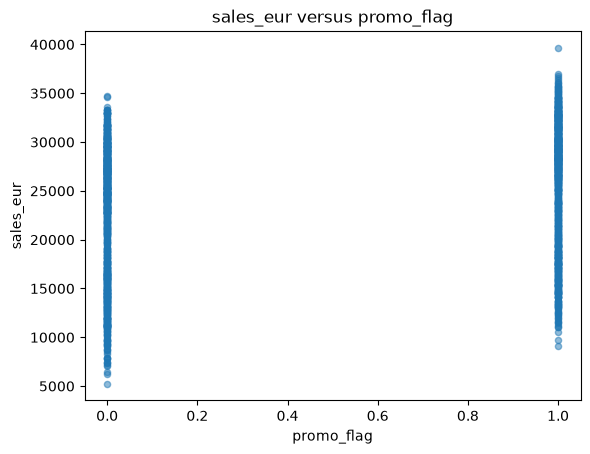

In [8]:
df.plot(x="promo_flag",y="sales_eur",kind="scatter",alpha=.5); plt.title("sales_eur versus promo_flag"); plt.show()

### Interpret `promo_flag`
**Evidence:** ...  
**Business interpretation:** ...  
**Caution:** ...

,week_start,observations,outcome
0,2023-01-01,15,23726.778667
1,2023-01-08,15,24559.448667
2,2023-01-15,15,24504.011333
3,2023-01-22,15,25092.002667
4,2023-01-29,15,26033.017333
...,...,...,...
115,2025-03-16,15,25298.854000
116,2025-03-23,15,25083.028667
117,2025-03-30,15,25958.473333
118,2025-04-06,15,24857.440667


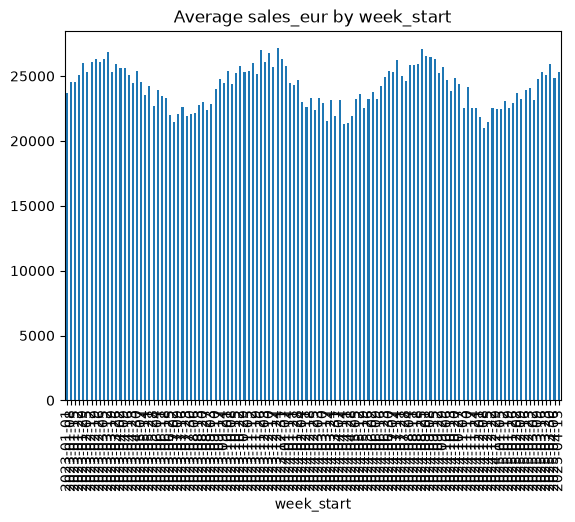

In [9]:
s=df.groupby("week_start",dropna=False).agg(observations=("sales_eur","size"),outcome=("sales_eur","mean")).reset_index()
display(s)
s.plot(x="week_start",y="outcome",kind="bar",legend=False); plt.title("Average sales_eur by week_start"); plt.show()

### Interpret `week_start`
**Evidence:** ...  
**Business interpretation:** ...  
**Caution:** ...

## 6. Three key insights
Select your three most important findings. For each provide evidence and explain its relevance to the business problem.

1. ...
2. ...
3. ...

## 7. Revisit Week 1 Business Understanding
1. What feedback did you receive?
2. What did you change because of it?
3. Which assumptions are supported by this data?
4. Which are challenged or remain uncertain?
5. Should your business problem, objective, success criteria or stakeholder perspective be refined? Explain.

### Your reflection
...

## 8. Limitations and next questions
What can this dataset not tell you? What important information is missing? What additional data would help? What questions should carry forward?

### Your answer
...

# Submission check
- [ ] All supplied code cells run successfully.
- [ ] All Markdown prompts are answered in my own words.
- [ ] I interpret evidence rather than copy output.
- [ ] I link findings to my Business Understanding.
- [ ] I explicitly reflect on Week 1 feedback.
- [ ] I distinguish association from causation.
- [ ] I identify quality concerns but do not perform Data Preparation.
- [ ] I submit the `.ipynb`.

**Deadline: 23 September 2026 at 13:00 (CET).**